In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import mean_squared_error

%env TF_CPP_MIN_LOG_LEVEL=3  # silence some TensorFlow warnings and logs

env: TF_CPP_MIN_LOG_LEVEL=3  # silence some TensorFlow warnings and logs


In [ ]:
a = np.arange(5)
b = np.arange(5)

a = tf.convert_to_tensor(a)
b = tf.convert_to_tensor(b)

print(a)
print(b)

b = tf.cast(b, tf.int64)

tf.Tensor([0 1 2 3 4], shape=(5,), dtype=int64)
tf.Tensor([0 1 2 3 4], shape=(5,), dtype=int64)


In [4]:
a = np.arange(24)
a = tf.convert_to_tensor(a)
a = tf.reshape(a,[2,3,4])
a

<tf.Tensor: shape=(2, 3, 4), dtype=int64, numpy=
array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])>

In [5]:
total = tf.reduce_sum(a)

avg = tf.reduce_mean(a,axis = 0)

In [ ]:
df = pd.read_csv(
    'https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt',
    delimiter='\t'
)
# rename columns
df.columns = [
    'age', 'sex', 'bmi', 'map',
    'tc', 'ldl', 'hdl', 'tch',
    'ltg', 'glu', 'disease_progression']



In [8]:
# get outcome
y = df['disease_progression'].values

# features
X = df[['age', 'sex', 'bmi', 'map', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']].values

# split into train and test
split = (0.7,0.3)
# shuffle the data by shuffling the indexes
shuffle = np.random.permutation(np.arange(y.shape[0]))

X,y = X[shuffle],y[shuffle]

splits = np.multiply(len(y),split).astype(int) # get the index of the splits as an integer (whole number)

X_train, X_test = np.split(X,[splits[0]])
y_train, y_test = np.split(y,[splits[0]])


In [9]:
# make a "train" df

df_train = pd.concat(
    [pd.DataFrame(y_train), pd.DataFrame(X_train)],axis=1)
# rename columns
df_train.columns=['disease_progression', 'age', 'sex', 'bmi', 'map',
    'tc', 'ldl', 'hdl', 'tch',
    'ltg', 'glu']


In [12]:
temp_X_train = X_train[:,2] # choose only BMI
temp_X_test = X_test[:,2]

# expand X so that it is 2D? makes it (133,) to (133,1)
temp_X_train = np.expand_dims(temp_X_train, axis=1) 
temp_X_test = np.expand_dims(temp_X_test, axis=1) 



In [13]:
def build_model(num_features):
    """Return a simple linear regression model using Keras Sequential API"""
    # clear session and set a seed for consistent behavior
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    # use keras sequential APO to build a lin reg
    model = tf.keras.Sequential()

    # create input layer
    model.add(tf.keras.Input(shape=(num_features,),name = 'Input'))

    # create output layer
    model.add(tf.keras.layers.Dense(
        activation = None,  # linear activation is used??
        units = 1,          # there is one singular output
        use_bias = True     # include a learned bias parameter??
    ))

    # use mean squared error as our loss and the adam optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.01)
    model.compile(loss = 'mse',optimizer=optimizer)

    return model

# Build the model
model = build_model(num_features = temp_X_train.shape[1])


In [14]:
# Now the model is an empty shell thats ready for me to put data into it

history = model.fit(
    x = temp_X_train, y=y_train,
    validation_data = [temp_X_test,y_test],
    batch_size = 12,
    epochs=50,
    verbose = 0
)


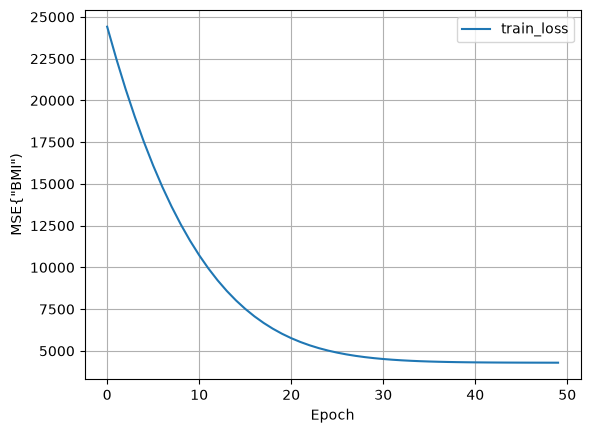

In [15]:
def plot_loss(history):
    plt.plot(history.history['loss'],label='train_loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE{"BMI")')
    plt.legend()
    plt.grid(True)

plot_loss(history)

In [17]:
# Run the trained model on the first 10 'BMI' train values
y_train_pred = model.predict(x=temp_X_train[:10]).flatten()

# Run the trained model on the first 10 'BMI' test values
y_test_pred = model.predict(x=temp_X_test[:10]).flatten()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [18]:
# compute MSE for test v train for whole data set

y_train_pred = model.predict(temp_X_train).flatten()
y_test_pred = model.predict(temp_X_test).flatten()

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print('MSE train:', mse_train)
print('MSE test:', mse_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 952us/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE train: 4291.6708984375
MSE test: 4318.703125
